In [2]:
# 환경설정
!pip install selenium webdriver-manager
import os
import platform
import time
import warnings
from pathlib import Path
import re
from urllib.parse import urljoin, urlparse
import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\JEON YUNA\my-first\ai-data-bootcamp\D011\안원잘부 숏츠 vs 원본 조회수 분석\d009_outputs


In [3]:
# 페이지에 요청을 보내고, 응답이 정상인지(200) 확인하기 , 정적 페이지인지 확인하기
url = "https://www.youtube.com/@helloiamwoninicetomeetyou/shorts"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

res = requests.get(url, headers=headers)
print(res.status_code)
print("거제 불주먹" in res.text)

200
True


In [4]:
# 숏츠 영상의 제목과 조회수 가져오기
pattern = r'"accessibilityText":"(.+?), 조회수 (.+?)회 - Shorts 동영상 재생"'
matches = re.findall(pattern, res.text)

print(f"찾은 개수: {len(matches)}")
for title, views in matches[:10]:
    print(title, "-", views)

찾은 개수: 48
Endless Rain - 86만
오빻 - 92만
거제 불주먹 양키 - 99만
원이의 꿈 - 47만
센빠이! - 119만
새로운 등교 친구 - 381만
좋지 않아? - 96만
서예하는 미나미 - 184만
고멘네! - 162만
장롱에 누군가 있다 - 86만


In [5]:
# 쇼츠에 원본 영상 링크가 걸려있는 경우가 대부분임. 쇼츠에 들어가야 정적이기 때문에 48개의 숏츠의 링크의 끝부분만 확인하고자함(바뀌는부분)
pattern2 = r'"entityId":"shorts-shelf-item-([\w-]+)","accessibilityText":"(.+?), 조회수 (.+?)회 - Shorts 동영상 재생"'
matches2 = re.findall(pattern2, res.text)

print(f"찾은 개수: {len(matches2)}")
for vid, title, views in matches2[:5]:
    print(vid, "-", title, "-", views)

찾은 개수: 48
F5CbMShscuk - Endless Rain - 86만
VUufd3Hd_2Q - 오빻 - 92만
qzhjmlxNl8s - 거제 불주먹 양키 - 99만
jilQNKreZBM - 원이의 꿈 - 47만
4ciHuGLi_1I - 센빠이! - 119만


In [6]:
# 숏츠 맨 뒤 영상 ID와 쇼츠 제목, 조회수를 데이터프레임으로 만듦
df_shorts = pd.DataFrame(matches2, columns=['영상ID', '제목', '조회수'])
print(df_shorts.shape)
print(df_shorts.head())

(48, 3)
          영상ID            제목   조회수
0  F5CbMShscuk  Endless Rain   86만
1  VUufd3Hd_2Q            오빻   92만
2  qzhjmlxNl8s     거제 불주먹 양키   99만
3  jilQNKreZBM         원이의 꿈   47만
4  4ciHuGLi_1I      센빠이!  119만


In [9]:
# 원본 링크로 들어갔을때 원본 영상 제목이 어디에 있는지 패턴 확인하기
test_url = "https://www.youtube.com/shorts/F5CbMShscuk"
res_test = requests.get(test_url, headers=headers)
idx = res_test.text.find('"reelCarouselButtonViewModel":{')  # 콜론+중괄호까지 포함
print(f"위치: {idx}")

if idx != -1:
    snippet = res_test.text[idx:idx+1500]
    print(snippet)

위치: 1093842
"reelCarouselButtonViewModel":{"buttonViewModel":{"buttonViewModel":{"onTap":{"innertubeCommand":{"clickTrackingParams":"CDQQycALIhMIoqPX7d7vlQMVano4BR1SmRbdygEEaDq1Hw==","commandMetadata":{"webCommandMetadata":{"url":"/watch?v=5spDxl-yzUQ","webPageType":"WEB_PAGE_TYPE_WATCH","rootVe":3832}},"watchEndpoint":{"videoId":"5spDxl-yzUQ"}}},"accessibilityText":"양키의 하루 배워보기 | 캐릭터 외전","style":"BUTTON_VIEW_MODEL_STYLE_OVERLAY","trackingParams":"CDQQycALIhMIoqPX7d7vlQMVano4BR1SmRbd","type":"BUTTON_VIEW_MODEL_TYPE_TONAL","buttonSize":"BUTTON_VIEW_MODEL_SIZE_XSMALL","accessibilityId":"id.reel_multi_format_link","titleFormatted":{"content":"양키의 하루 배워보기 | 캐릭터 외전","styleRuns":[{"startIndex":0,"length":48,"fontName":""}]},"iconImage":{"clientResource":{"imageName":"PLAY_ARROW","imageColor":4294967295}},"loggingDirectives":{"trackingParams":"CDQQycALIhMIoqPX7d7vlQMVano4BR1SmRbd","visibility":{"types":"12"},"attentionLogging":"ATTENTION_LOGGING_BASIC"}}},"maxWidthPercent":0.94999999}}],"enab

In [10]:
# 원본 영상 끝 ID와 제목 가져와보기 - 일단하나만
def get_original_video(short_id, headers):
    url = f"https://www.youtube.com/shorts/{short_id}"
    res = requests.get(url, headers=headers)
    
    idx = res.text.find('"reelCarouselButtonViewModel":{')
    if idx == -1:
        return None, None
    
    snippet = res.text[idx:idx+1000]
    
    id_match = re.search(r'"videoId":"([\w-]+)"', snippet)
    title_match = re.search(r'"accessibilityText":"(.+?)"', snippet)
    
    orig_id = id_match.group(1) if id_match else None
    orig_title = title_match.group(1) if title_match else None
    
    return orig_id, orig_title

# 테스트
test_id, test_title = get_original_video('F5CbMShscuk', headers)
print(test_id, test_title)

5spDxl-yzUQ 양키의 하루 배워보기 | 캐릭터 외전


In [11]:
# 숏츠 안에서 원본 영상 끝 ID들 전부 가져오기 , 그리고 제목도 가져오기
original_links = []

for idx, row in df_shorts.iterrows():
    short_id = row['영상ID']
    orig_id, orig_title = get_original_video(short_id, headers)
    
    original_links.append({
        '쇼츠ID': short_id,
        '쇼츠제목': row['제목'],
        '쇼츠조회수': row['조회수'],
        '원본ID': orig_id,
        '원본제목': orig_title
    })
    
    print(f"{idx+1}/48 완료: {short_id} → {orig_id}")
    time.sleep(1)  # 서버 부담 줄이기

# 데이터프레임으로 만들기
df_original = pd.DataFrame(original_links)
print(df_original)

#참고로 None은 롱폼 없이 숏츠만 있는 경우(광고), 아니면 원본링크가 없는경우임

1/48 완료: F5CbMShscuk → 5spDxl-yzUQ
2/48 완료: VUufd3Hd_2Q → 5spDxl-yzUQ
3/48 완료: qzhjmlxNl8s → 5spDxl-yzUQ
4/48 완료: jilQNKreZBM → Yy58f1A6F-c
5/48 완료: 4ciHuGLi_1I → Yy58f1A6F-c
6/48 완료: FxbR-V8GOjE → Yy58f1A6F-c
7/48 완료: tDs3mcabrFM → Yy58f1A6F-c
8/48 완료: 5qmyo1nR3no → wdH5_I7UiHA
9/48 완료: GUHzPMtxAqY → wdH5_I7UiHA
10/48 완료: y2TOOxHF35E → wdH5_I7UiHA
11/48 완료: beKjAiS8n44 → None
12/48 완료: Gnf3QzdopbM → None
13/48 완료: YDCgJIvro-4 → XD3rCGvMPJE
14/48 완료: LVr2R5_TFME → XD3rCGvMPJE
15/48 완료: cDDORzB-2Q0 → XD3rCGvMPJE
16/48 완료: 5zg26mxu4_w → None
17/48 완료: P5GHz5HW9Uk → 5JZ5biQ_hMI
18/48 완료: ORksT1QDf3k → 5JZ5biQ_hMI
19/48 완료: 6cPEEeEAKiM → SF29doLuBfc
20/48 완료: OmjUI2EQiPw → SF29doLuBfc
21/48 완료: XJQMnwcMvcw → None
22/48 완료: 510hBsWhh0A → None
23/48 완료: nHY4EK0kVH0 → JJBf0jCcfrQ
24/48 완료: hrFWuCyHXpY → JJBf0jCcfrQ
25/48 완료: gRESmZMqlFA → JJBf0jCcfrQ
26/48 완료: xsNWeKpL5IQ → None
27/48 완료: yFyk6KPsGuA → None
28/48 완료: IQ4MGDgdr5I → None
29/48 완료: PiKBQ65QE1g → None
30/48 완료: m-MBLSS70x0 → None

In [12]:
# 데이터프레임 미리보기
df_original.head(10)

,쇼츠ID,쇼츠제목,쇼츠조회수,원본ID,원본제목
0,F5CbMShscuk,Endless Rain,86만,5spDxl-yzUQ,양키의 하루 배워보기 | 캐릭터 외전
1,VUufd3Hd_2Q,오빻,92만,5spDxl-yzUQ,양키의 하루 배워보기 | 캐릭터 외전
2,qzhjmlxNl8s,거제 불주먹 양키,99만,5spDxl-yzUQ,양키의 하루 배워보기 | 캐릭터 외전
3,jilQNKreZBM,원이의 꿈,47만,Yy58f1A6F-c,미나미의 뿌리를 찾아서 | 최종화
4,4ciHuGLi_1I,센빠이!,119만,Yy58f1A6F-c,미나미의 뿌리를 찾아서 | 최종화
5,FxbR-V8GOjE,새로운 등교 친구,381만,Yy58f1A6F-c,미나미의 뿌리를 찾아서 | 최종화
6,tDs3mcabrFM,좋지 않아?,96만,Yy58f1A6F-c,미나미의 뿌리를 찾아서 | 최종화
7,5qmyo1nR3no,서예하는 미나미,184만,wdH5_I7UiHA,미나미의 본모습
8,GUHzPMtxAqY,고멘네!,162만,wdH5_I7UiHA,미나미의 본모습
9,y2TOOxHF35E,장롱에 누군가 있다,86만,wdH5_I7UiHA,미나미의 본모습


In [13]:
# 데이터 더 자세히 보기
print(df_original.shape)
print(df_original['원본ID'].isnull().sum())  # 원본을 못 찾은 쇼츠가 있는지
print(df_original['원본ID'].nunique())  # 고유한 원본 영상이 몇 개인지

(48, 5)
10
12


In [14]:
# 원본과 연결되지 않는 숏츠에 대한 값들은 제거한다 48 -> 38
df_matched = df_original.dropna(subset=['원본ID'])
print(df_matched.shape)  # (38, 5) 나와야 정상

(38, 5)


In [15]:
# 하나의 영상으로도 여러개의 쇼츠를 만들기 때문에 고유한 원본영상은 몇 개인지 확인
unique_original_ids = df_matched['원본ID'].unique()
print(f"고유 원본 영상 개수: {len(unique_original_ids)}")
print(unique_original_ids)

고유 원본 영상 개수: 12
<ArrowStringArray>
['5spDxl-yzUQ', 'Yy58f1A6F-c', 'wdH5_I7UiHA', 'XD3rCGvMPJE', '5JZ5biQ_hMI',
 'SF29doLuBfc', 'JJBf0jCcfrQ', 'OrCOflk2QmQ', 'NS7tSrMrWsc', 'FcMaC8akSU8',
 'inaTPJiZ734', 'heifaIjlSUc']
Length: 12, dtype: str


In [16]:
videos_url = "https://www.youtube.com/@helloiamwoninicetomeetyou/videos"
res_videos = requests.get(videos_url, headers=headers)
print(res_videos.status_code)

# 아까 쇼츠에서 썼던 것과 비슷한 패턴이 있는지 확인
# 먼저 원본 영상 중 하나("양키의 하루 배워보기")가 이 페이지에 있는지 확인
print("양키의 하루 배워보기" in res_videos.text)

200
True


In [17]:
# 원본영상에서 조회수가 어디에 있는지 확인하기
idx = res_videos.text.find("양키의 하루 배워보기")
print(res_videos.text[idx-200:idx+300])

ZE_COMPACT","state":"BUTTON_VIEW_MODEL_STATE_ACTIVE"}},"isToggled":false,"trackingParams":"CPoBENTEDCITCJurscTf75UDFbGYVgEdiPco_A=="}}]}}]}},"metadata":{"lockupMetadataViewModel":{"title":{"content":"양키의 하루 배워보기 | 캐릭터 외전"},"metadata":{"contentMetadataViewModel":{"metadataRows":[{"metadataParts":[{"text":{"content":"조회수 328만회"}},{"text":{"content":"2주 전"},"accessibilityLabel":"2주 전"}]}],"delimiter":" • "}},"menuButton":{"buttonViewModel":{"iconName":"MORE_VERT","onTap":{"innertubeCommand":{"click


In [18]:
# 원본영상 제목이랑 조회수 매칭하기
blocks = res_videos.text.split('"lockupMetadataViewModel":{')

results = []
for block in blocks[1:]:
    title_match = re.search(r'"title":\{"content":"(.+?)"\}', block[:500])
    view_match = re.search(r'"조회수 (.+?)회"', block[:1000])
    
    if title_match and view_match:
        results.append((title_match.group(1), view_match.group(1)))

print(f"찾은 개수: {len(results)}")
for title, views in results:
    print(title, "-", views)

찾은 개수: 23
안원잘부 미방분 - 211만
양키의 하루 배워보기 | 캐릭터 외전 - 328만
미나미의 뿌리를 찾아서 | 최종화 - 456만
미나미의 본모습 - 639만
갑자기 떡상해서 찍는 댓글읽기 - 332만
진짜 '야호' 하는지 물어봤습니다 - 515만
저희도 리센느입니다... - 884만
갸루와 거제 2편 - 552만
떡상 전 성수나들이 (사투리2편) - 680만
갸루와 거제에 왔습니다 (거제 1편) - 1098만
선배지만 친구가 하고 싶어 - 280만
미나미에게 위협을 느끼나요? | 10만 기념 Q\u0026A - 392만
하루종일 사투리만 써봤습니다 - 828만
유영우 삼촌과 눈물 참기 대결 - 170만
미나미의 갸루라이브 메들리! - 698만
인생 첫 파인다이닝에 간 셋 - 433만
갸루의 자세에 대해서 배워보았습니다 - 390만
갸루 출신 일본인에게 일본어 배우기 - 323만
인간에게 가장 위험한 동물 TOP 5 (사망률 기준) - 64만
정일영 교수님과 달팽이 요리 - 76만
곰을 만났을 때 대처법 (상상편) - 80만
곰을 만났을 때 대처법 (실전편) - 159만
선민 삼촌과 콩나물 국밥 - 210만


In [19]:
# 원본제목과 조회수로 데이터프레임 만들기
df_video_views = pd.DataFrame(results, columns=['원본제목', '원본조회수'])
print(df_video_views)

                                 원본제목  원본조회수
0                            안원잘부 미방분   211만
1                양키의 하루 배워보기 | 캐릭터 외전   328만
2                  미나미의 뿌리를 찾아서 | 최종화   456만
3                            미나미의 본모습   639만
4                    갑자기 떡상해서 찍는 댓글읽기   332만
5                  진짜 '야호' 하는지 물어봤습니다   515만
6                       저희도 리센느입니다...   884만
7                           갸루와 거제 2편   552만
8                  떡상 전 성수나들이 (사투리2편)   680만
9                갸루와 거제에 왔습니다 (거제 1편)  1098만
10                     선배지만 친구가 하고 싶어   280만
11  미나미에게 위협을 느끼나요? | 10만 기념 Q\u0026A   392만
12                    하루종일 사투리만 써봤습니다   828만
13                   유영우 삼촌과 눈물 참기 대결   170만
14                    미나미의 갸루라이브 메들리!   698만
15                    인생 첫 파인다이닝에 간 셋   433만
16                갸루의 자세에 대해서 배워보았습니다   390만
17                갸루 출신 일본인에게 일본어 배우기   323만
18      인간에게 가장 위험한 동물 TOP 5 (사망률 기준)    64만
19                    정일영 교수님과 달팽이 요리    76만
20                 곰을 만났을 때 대처법 (상상편)    80만
21        

In [25]:
# 위에서 만들었던 쇼츠 관련 데이터프레임과 원본 관련 데이터프레임 합치기
final_compare = df_matched.merge(df_video_views, on='원본제목', how='left')
print(final_compare.shape)
print(final_compare)


(38, 6)
           쇼츠ID               쇼츠제목 쇼츠조회수         원본ID                  원본제목  \
0   F5CbMShscuk       Endless Rain   86만  5spDxl-yzUQ  양키의 하루 배워보기 | 캐릭터 외전   
1   VUufd3Hd_2Q                 오빻   92만  5spDxl-yzUQ  양키의 하루 배워보기 | 캐릭터 외전   
2   qzhjmlxNl8s          거제 불주먹 양키   99만  5spDxl-yzUQ  양키의 하루 배워보기 | 캐릭터 외전   
3   jilQNKreZBM              원이의 꿈   47만  Yy58f1A6F-c    미나미의 뿌리를 찾아서 | 최종화   
4   4ciHuGLi_1I           센빠이!  119만  Yy58f1A6F-c    미나미의 뿌리를 찾아서 | 최종화   
5   FxbR-V8GOjE   새로운 등교 친구  381만  Yy58f1A6F-c    미나미의 뿌리를 찾아서 | 최종화   
6   tDs3mcabrFM             좋지 않아?   96만  Yy58f1A6F-c    미나미의 뿌리를 찾아서 | 최종화   
7   5qmyo1nR3no   서예하는 미나미  184만  wdH5_I7UiHA              미나미의 본모습   
8   GUHzPMtxAqY               고멘네!  162만  wdH5_I7UiHA              미나미의 본모습   
9   y2TOOxHF35E         장롱에 누군가 있다   86만  wdH5_I7UiHA              미나미의 본모습   
10  YDCgJIvro-4         혹시 한국인이세요?  407만  XD3rCGvMPJE    진짜 '야호' 하는지 물어봤습니다   
11  LVr2R5_TFME            갸루 팩트체크  403만  XD

In [24]:
print(final_compare[['쇼츠제목', '쇼츠조회수', '원본제목', '원본조회수']])

                 쇼츠제목 쇼츠조회수                  원본제목  원본조회수
0        Endless Rain   86만  양키의 하루 배워보기 | 캐릭터 외전   328만
1                  오빻   92만  양키의 하루 배워보기 | 캐릭터 외전   328만
2           거제 불주먹 양키   99만  양키의 하루 배워보기 | 캐릭터 외전   328만
3               원이의 꿈   47만    미나미의 뿌리를 찾아서 | 최종화   456만
4            센빠이!  119만    미나미의 뿌리를 찾아서 | 최종화   456만
5    새로운 등교 친구  381만    미나미의 뿌리를 찾아서 | 최종화   456만
6              좋지 않아?   96만    미나미의 뿌리를 찾아서 | 최종화   456만
7    서예하는 미나미  184만              미나미의 본모습   639만
8                고멘네!  162만              미나미의 본모습   639만
9          장롱에 누군가 있다   86만              미나미의 본모습   639만
10         혹시 한국인이세요?  407만    진짜 '야호' 하는지 물어봤습니다   515만
11            갸루 팩트체크  403만    진짜 '야호' 하는지 물어봤습니다   515만
12        일본에서 먹히는 발음  329만    진짜 '야호' 하는지 물어봤습니다   515만
13   우리도 리센느야  488만         저희도 리센느입니다...   884만
14         화난 갸루  610만         저희도 리센느입니다...   884만
15              갸루 귀신   87만             갸루와 거제 2편   552만
16            학창시절 인기  112만    

In [ ]:
# 결측치 없음 확인하기
print(final_compare.shape)
print(final_compare[['쇼츠조회수', '원본조회수']].isnull().sum())

(38, 6)
쇼츠조회수    0
원본조회수    0
dtype: int64


In [26]:
final_compare.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   쇼츠ID    38 non-null     str  
 1   쇼츠제목    38 non-null     str  
 2   쇼츠조회수   38 non-null     str  
 3   원본ID    38 non-null     str  
 4   원본제목    38 non-null     str  
 5   원본조회수   38 non-null     str  
dtypes: str(6)
memory usage: 5.6 KB


In [27]:
# 조회수 숫자로 자료형 바꾸기
def convert_views(text):
    text = str(text).replace(',', '')
    if '만' in text:
        return float(text.replace('만', '')) * 10000
    elif '억' in text:
        return float(text.replace('억', '')) * 100000000
    else:
        return float(text)

final_compare['쇼츠조회수_숫자'] = final_compare['쇼츠조회수'].apply(convert_views)
final_compare['원본조회수_숫자'] = final_compare['원본조회수'].apply(convert_views)

print(final_compare[['쇼츠제목', '쇼츠조회수_숫자', '원본제목', '원본조회수_숫자']])

                 쇼츠제목   쇼츠조회수_숫자                  원본제목    원본조회수_숫자
0        Endless Rain   860000.0  양키의 하루 배워보기 | 캐릭터 외전   3280000.0
1                  오빻   920000.0  양키의 하루 배워보기 | 캐릭터 외전   3280000.0
2           거제 불주먹 양키   990000.0  양키의 하루 배워보기 | 캐릭터 외전   3280000.0
3               원이의 꿈   470000.0    미나미의 뿌리를 찾아서 | 최종화   4560000.0
4            센빠이!  1190000.0    미나미의 뿌리를 찾아서 | 최종화   4560000.0
5    새로운 등교 친구  3810000.0    미나미의 뿌리를 찾아서 | 최종화   4560000.0
6              좋지 않아?   960000.0    미나미의 뿌리를 찾아서 | 최종화   4560000.0
7    서예하는 미나미  1840000.0              미나미의 본모습   6390000.0
8                고멘네!  1620000.0              미나미의 본모습   6390000.0
9          장롱에 누군가 있다   860000.0              미나미의 본모습   6390000.0
10         혹시 한국인이세요?  4070000.0    진짜 '야호' 하는지 물어봤습니다   5150000.0
11            갸루 팩트체크  4030000.0    진짜 '야호' 하는지 물어봤습니다   5150000.0
12        일본에서 먹히는 발음  3290000.0    진짜 '야호' 하는지 물어봤습니다   5150000.0
13   우리도 리센느야  4880000.0         저희도 리센느입니다...   88400

In [29]:
# 최종 비교 데이터 저장 (38개, 쇼츠-원본 매칭)
final_compare.to_csv('shorts_vs_original.csv', index=False, encoding='utf-8-sig')

print('저장 완료: shorts_vs_original.csv')

저장 완료: shorts_vs_original.csv


In [ ]:
# 같은 원본영상으로부터 나온 숏츠의 평균 조회수를 계산하기
grouped = final_compare.groupby('원본제목').agg(
    쇼츠평균조회수=('쇼츠조회수_숫자', 'mean'),
    쇼츠개수=('쇼츠조회수_숫자', 'count'),
    원본조회수=('원본조회수_숫자', 'first')
).reset_index()

print(grouped)

                    원본제목       쇼츠평균조회수  쇼츠개수       원본조회수
0              갸루와 거제 2편  9.950000e+05     2   5520000.0
1   갸루와 거제에 왔습니다 (거제 1편)  3.500000e+06     4  10980000.0
2    갸루의 자세에 대해서 배워보았습니다  4.310000e+06     2   3900000.0
3     떡상 전 성수나들이 (사투리2편)  3.970000e+06     3   6800000.0
4        미나미의 갸루라이브 메들리!  3.060000e+06     4   6980000.0
5               미나미의 본모습  1.440000e+06     3   6390000.0
6     미나미의 뿌리를 찾아서 | 최종화  1.607500e+06     4   4560000.0
7   양키의 하루 배워보기 | 캐릭터 외전  9.233333e+05     3   3280000.0
8        인생 첫 파인다이닝에 간 셋  3.400000e+05     2   4330000.0
9          저희도 리센느입니다...  5.490000e+06     2   8840000.0
10    진짜 '야호' 하는지 물어봤습니다  3.796667e+06     3   5150000.0
11       하루종일 사투리만 써봤습니다  2.798333e+06     6   8280000.0


In [32]:
# 원본 단위로 그룹화한 데이터도 저장 (12개)
grouped.to_csv('shorts_grouped_by_original.csv', index=False, encoding='utf-8-sig')

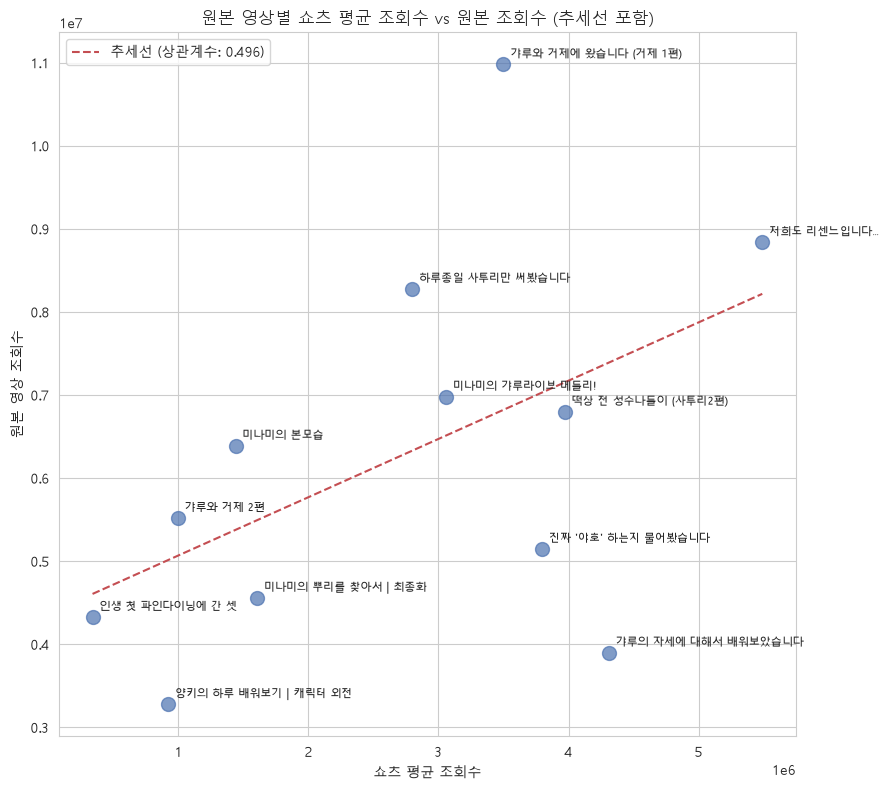

In [ ]:
# 숏츠 평균 조회수와 원본 영상 조회수의 상관관계보기
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(grouped['쇼츠평균조회수'], grouped['원본조회수'], s=100, color='#4C72B0', alpha=0.7)

# 추세선 추가
z = np.polyfit(grouped['쇼츠평균조회수'], grouped['원본조회수'], 1)
p = np.poly1d(z)
x_line = np.linspace(grouped['쇼츠평균조회수'].min(), grouped['쇼츠평균조회수'].max(), 100)
correlation = grouped['쇼츠평균조회수'].corr(grouped['원본조회수'])
ax.plot(x_line, p(x_line), color='#C44E52', linestyle='--', label=f'추세선 (상관계수: {correlation:.3f})')

for i, row in grouped.iterrows():
    ax.annotate(row['원본제목'], 
                (row['쇼츠평균조회수'], row['원본조회수']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('쇼츠 평균 조회수')
ax.set_ylabel('원본 영상 조회수')
ax.set_title('원본 영상별 쇼츠 평균 조회수 vs 원본 조회수 (추세선 포함)')
ax.legend()

plt.tight_layout()
plt.show()

-> 쇼츠 평균 조회수와 원본 영상 조회수 사이의 상관계수는 0.496으로, 중간 정도의 양의 상관관계를 보였다. 즉 쇼츠 조회수가 높은 영상일수록 원본 영상 조회수도 대체로 높아지는 경향이 있지만, 그 관계가 아주 강하지는 않았다. 실제로 "가루의 자세에 대해서 배워보았습니다"처럼 쇼츠 평균 조회수는 높지만(약 430만) 원본 조회수는 상대적으로 낮은(약 390만) 예외 사례도 존재해, 쇼츠의 인기가 항상 원본 영상의 성과로 직결되지는 않는다는 것을 알 수 있다.

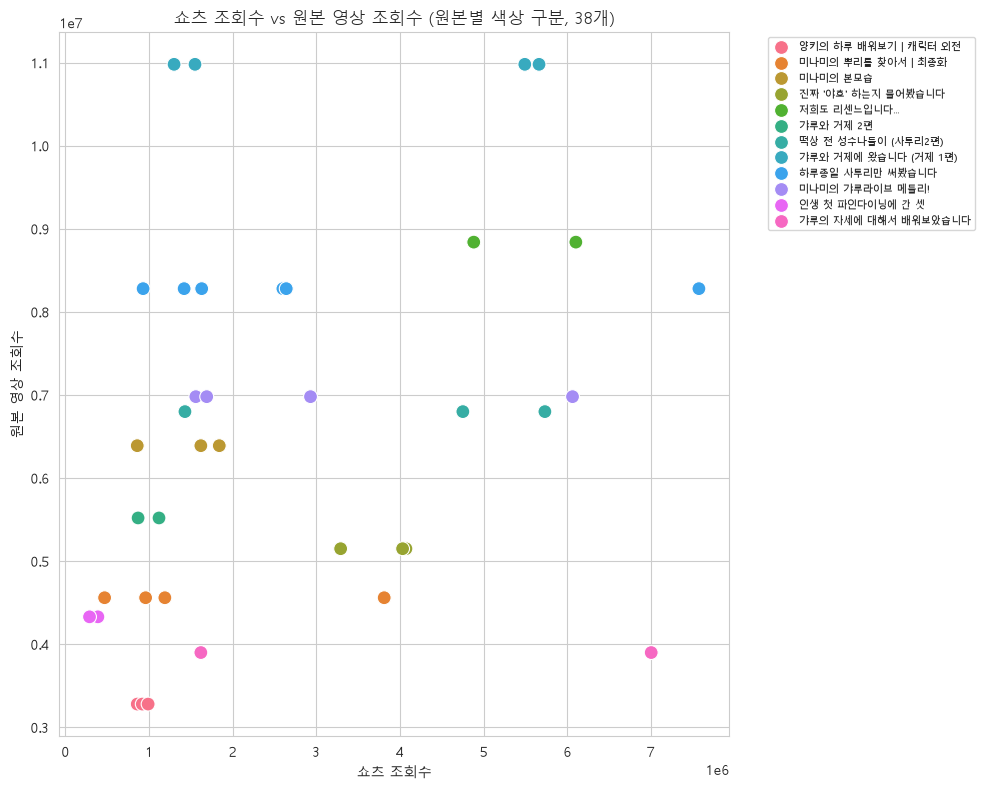

In [ ]:
# 평균 대신 색깔로 구분하기
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=final_compare, x='쇼츠조회수_숫자', y='원본조회수_숫자', 
                 hue='원본제목', s=100, ax=ax)
ax.set_xlabel('쇼츠 조회수')
ax.set_ylabel('원본 영상 조회수')
ax.set_title('쇼츠 조회수 vs 원본 영상 조회수 (원본별 색상 구분, 38개)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

-> 쇼츠 평균 조회수와 원본 영상 조회수 사이의 상관계수는 0.496으로 중간 정도의 양의 상관관계를 보였다. 38개 쇼츠를 원본별로 색상 구분해서 보면, 같은 원본에서 나온 쇼츠들은 원본 조회수(y값)가 동일하게 수평선을 이루는 구조가 뚜렷하게 나타난다. 대체로 쇼츠 조회수가 높은 그룹(파란색, 초록색 계열)이 원본 조회수도 높은 편으로 나타나 어느 정도 관계가 있음을 확인할 수 있었다. 다만 "가루의 자세에 대해서 배워보았습니다" 쇼츠는 조회수가 700만으로 전체 중 가장 높았음에도 원본 영상 조회수는 390만으로 상대적으로 낮아, 쇼츠 하나의 높은 인기가 항상 원본 영상 조회로 이어지지는 않는다는 예외적 사례를 보여준다.

쇼츠 개수 vs 원본 조회수 상관계수: 0.412


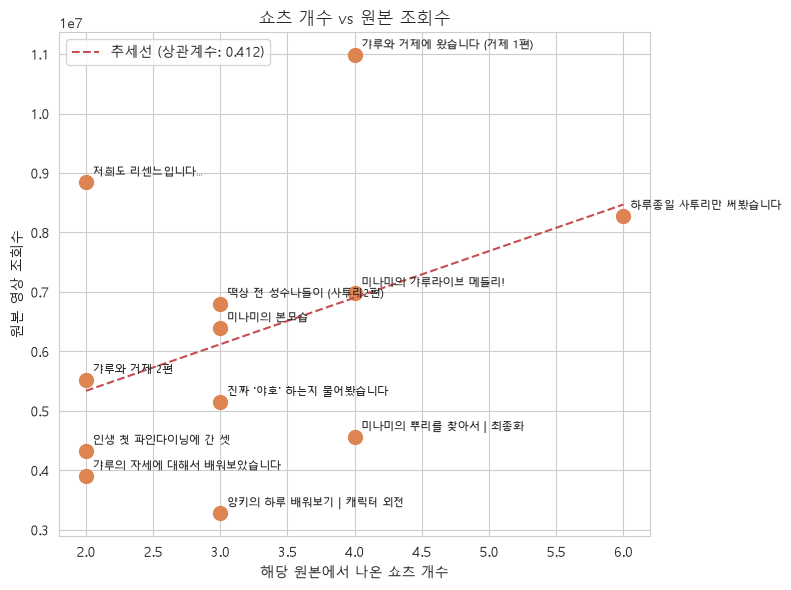

In [42]:
# 숏츠의 개수와 원본 조회수의 상관관계도 보기
correlation2 = grouped['쇼츠개수'].corr(grouped['원본조회수'])
print(f"쇼츠 개수 vs 원본 조회수 상관계수: {correlation2:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(grouped['쇼츠개수'], grouped['원본조회수'], s=100, color='#DD8452')

# 추세선 추가
z2 = np.polyfit(grouped['쇼츠개수'], grouped['원본조회수'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(grouped['쇼츠개수'].min(), grouped['쇼츠개수'].max(), 100)
ax.plot(x_line2, p2(x_line2), color='#C44E52', linestyle='--', label=f'추세선 (상관계수: {correlation2:.3f})')

for i, row in grouped.iterrows():
    ax.annotate(row['원본제목'], (row['쇼츠개수'], row['원본조회수']), 
                textcoords="offset points", xytext=(5,5), fontsize=8)

ax.set_xlabel('해당 원본에서 나온 쇼츠 개수')
ax.set_ylabel('원본 영상 조회수')
ax.set_title('쇼츠 개수 vs 원본 조회수')
ax.legend()

plt.tight_layout()
plt.show()

-> 쇼츠 개수와 원본 조회수 사이의 상관계수는 0.412로, 약~중간 정도의 양의 상관관계를 보였다. "갸루와 거제에 왔습니다(거제 1편)"는 쇼츠 4개로 원본 조회수도 1,098만으로 가장 높았고, "하루종일 사투리만 써봤습니다"는 쇼츠 6개(가장 많음)로 원본 조회수 828만을 기록해 대체로 쇼츠 개수가 많을수록 원본 조회수도 높아지는 경향을 보였다. 다만 "저희도 리센느입니다..."는 쇼츠가 2개뿐인데도 원본 조회수가 885만으로 매우 높았고, 반대로 "미나미의 뿌리를 찾아서 | 최종화"는 쇼츠 3개인데도 원본 조회수가 456만에 그쳐, 쇼츠 개수만으로 원본 조회수를 설명하기는 어려웠다. 이는 Q1(쇼츠 평균 조회수 vs 원본 조회수, 상관계수 0.496)과 비교했을 때도 관계가 더 약해, "쇼츠를 몇 개 만들었는가"보다는 "그 쇼츠들이 실제로 얼마나 많이 보였는가"가 원본 조회수와 조금 더 관련이 깊다는 것을 시사한다.